In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [173]:
# Load training dataset

df = pd.read_csv("train.csv", index_col = "Id")

In [174]:
# Inspect data

print("Dataframe shape: ", df.shape)

print("Missing values: ", df.isnull().sum().sum())

print(df.dtypes)

df.head()


Dataframe shape:  (1460, 80)
Missing values:  7829
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
Street               str
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 80, dtype: object


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [175]:
# Numeric feature EDA, exlude SalePrice

numeric_cols = df.select_dtypes(np.number).columns.drop("SalePrice")

print("Numeric columns: ", len(numeric_cols))

format(numeric_cols)

Numeric columns:  36


"Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',\n       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',\n       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',\n       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',\n       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',\n       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',\n       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',\n       'MoSold', 'YrSold'],\n      dtype='str')"

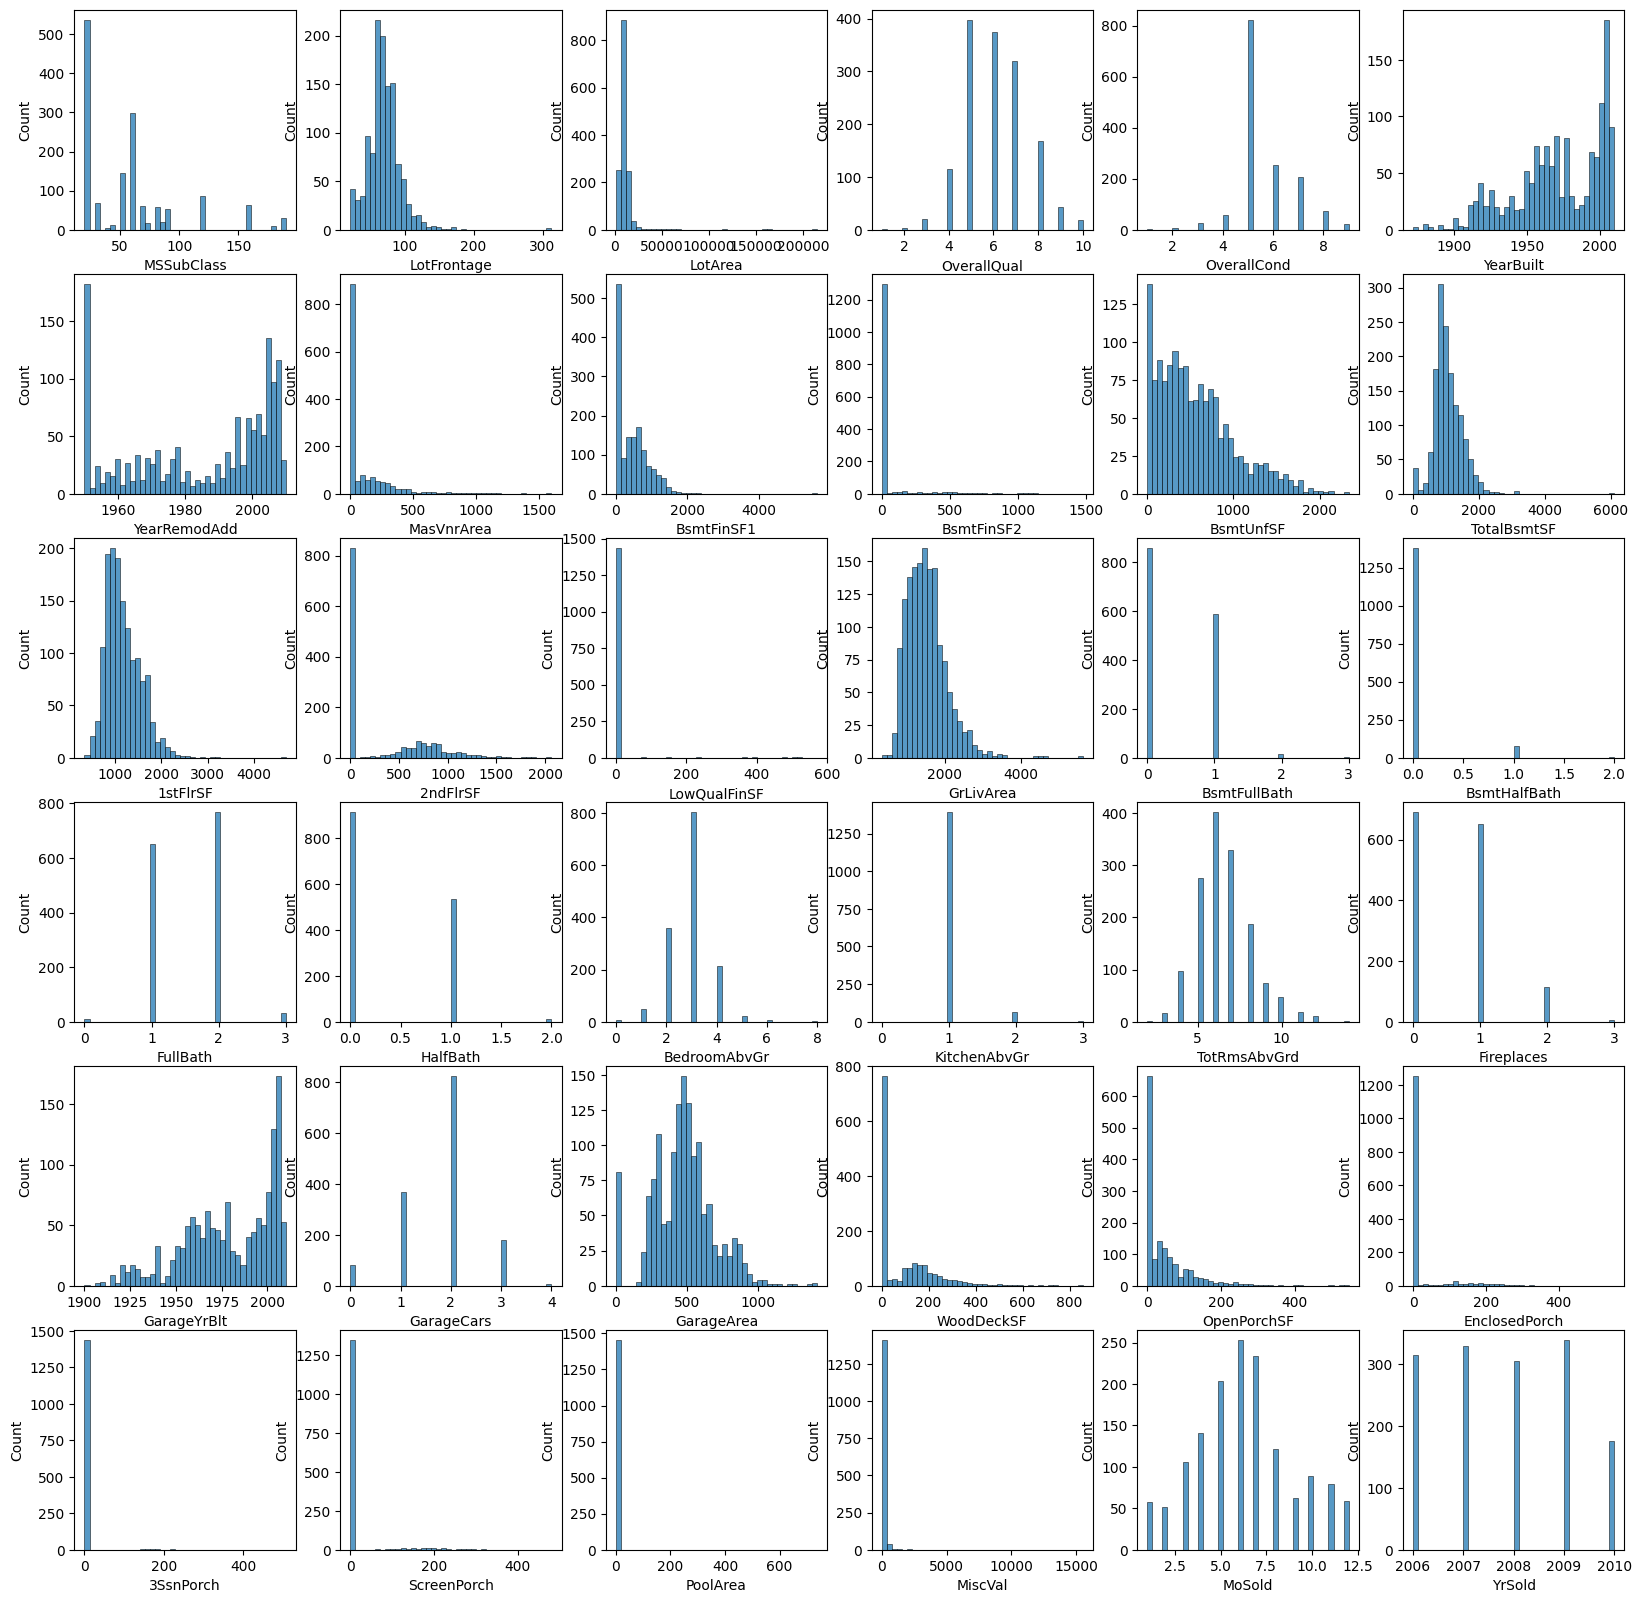

In [176]:
# Plot feature distributions in 6 x 6 grid (exclude SalePrice)

fig, axes = plt.subplots(6, 6, sharex = False, sharey = False, figsize = (20, 20))

# Make looping easier
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins = 40, ax = axes[i])

In [177]:
# Create cols to drop variable before model building

cols_to_drop = []

In [178]:
# Derive binary has_pool variable

df["has_pool"] = np.where(df["PoolArea"] > 0, True, False)

df[df["has_pool"] == True][["PoolArea", "PoolQC", "has_pool"]].head()

cols_to_drop.append("PoolArea")
cols_to_drop.append("PoolQC")

In [179]:
# Derive house_age and remodel_age variables

house_age_cols = ["YrSold", "YearBuilt", "YearRemodAdd"]

df["house_age"] = df["YrSold"] + (df["MoSold"]/12) - df["YearBuilt"]

df["remodel_age"] = df["YrSold"] + (df["MoSold"]/12) - df["YearRemodAdd"]

df[["YrSold", "YearBuilt", "YearRemodAdd", "house_age", "remodel_age"]].head()

for i in range(len(house_age_cols)):
    cols_to_drop.append(house_age_cols[i])

cols_to_drop

['PoolArea', 'PoolQC', 'YrSold', 'YearBuilt', 'YearRemodAdd']

In [180]:
df["MoSold"] = df["MoSold"].map(str)

In [181]:
# Derive total_house_area (sq feet)

house_area_cols = ["1stFlrSF", "2ndFlrSF"]

df["total_house_area"] =  df["1stFlrSF"] + df["2ndFlrSF"]

cols_to_drop.append("1stFlrSF")
cols_to_drop.append("2ndFlrSF")

In [182]:
# Derive total_porch_area (sq feet)

porch_cols = ["EnclosedPorch", "3SsnPorch", "ScreenPorch"]

for i in range(len(porch_cols)):
    cols_to_drop.append(porch_cols[i])

df["total_porch_area"] = df["EnclosedPorch"] + df["3SsnPorch"] + df["ScreenPorch"]

df[["EnclosedPorch", "3SsnPorch", "ScreenPorch", "total_porch_area"]].head()


,EnclosedPorch,3SsnPorch,ScreenPorch,total_porch_area
Id,,,,
1,0,0,0,0
2,0,0,0,0
3,0,0,0,0
4,272,0,0,272
5,0,0,0,0


In [183]:
# Create has_shed variable

df["MiscFeature"].value_counts()

df["has_shed"] = df["MiscFeature"] == "Shed"

cols_to_drop.append("MiscFeature")

df["has_shed"]



Id
1       False
2       False
3       False
4       False
5       False
        ...  
1456    False
1457    False
1458     True
1459    False
1460    False
Name: has_shed, Length: 1460, dtype: bool

In [184]:
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)
null_counts

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [185]:
print(df["Alley"].value_counts())

cols_to_drop.append("Alley")

Alley
Grvl    50
Pave    41
Name: count, dtype: int64


In [186]:
# Create has_fence variable

df["Fence"].value_counts()

df["has_fence"] = ~df["Fence"].isnull()

cols_to_drop.append("Fence")

df[["has_fence", "Fence"]]

,has_fence,Fence
Id,,
1,False,NaN
2,False,NaN
3,False,NaN
4,False,NaN
5,False,NaN
...,...,...
1456,False,NaN
1457,True,MnPrv
1458,True,GdPrv


In [187]:
# Replacing missing MasVnrType with None, and MasVnrArea with 0

df["MasVnrType"] = df["MasVnrType"].fillna("None")

df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

df["MasVnrType"].value_counts()


MasVnrType
None       872
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

In [188]:
# Convert LotFrontage null to zero

df["LotFrontage"] = df["LotFrontage"].fillna(0)

df["LotFrontage"].isnull().sum()

np.int64(0)

In [189]:
# Drop FireplaceQu as already have Fireplaces (no. of fireplaces)

cols_to_drop.append("FireplaceQu") 

In [190]:
# Drop all garage features except GarageArea as redundant

garage_feature_list = ["GarageType", "GarageYrBlt", "GarageFinish", "GarageCars", "GarageQual", "GarageCond"]

for i in range(len(garage_feature_list)):
    cols_to_drop.append(garage_feature_list[i])

In [191]:
# Drop all basement features except TotalBsmtSF as redundant

basement_feature_list = ["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinSF1", "BsmtFinType2", "BsmtFinSF2", "BsmtUnfSF"]

for i in range(len(basement_feature_list)):
    cols_to_drop.append(basement_feature_list[i])

In [192]:
df_dropped = df.drop(set(cols_to_drop), axis=1)

In [193]:
df_dropped.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,SaleType,SaleCondition,SalePrice,has_pool,house_age,remodel_age,total_house_area,total_porch_area,has_shed,has_fence
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,WD,Normal,208500,False,5.166667,5.166667,1710,0,False,False
2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,WD,Normal,181500,False,31.416667,31.416667,1262,0,False,False
3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,WD,Normal,223500,False,7.750000,6.750000,1786,0,False,False
4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,WD,Abnorml,140000,False,91.166667,36.166667,1717,272,False,False
5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,WD,Normal,250000,False,9.000000,9.000000,2198,0,False,False


<Axes: >

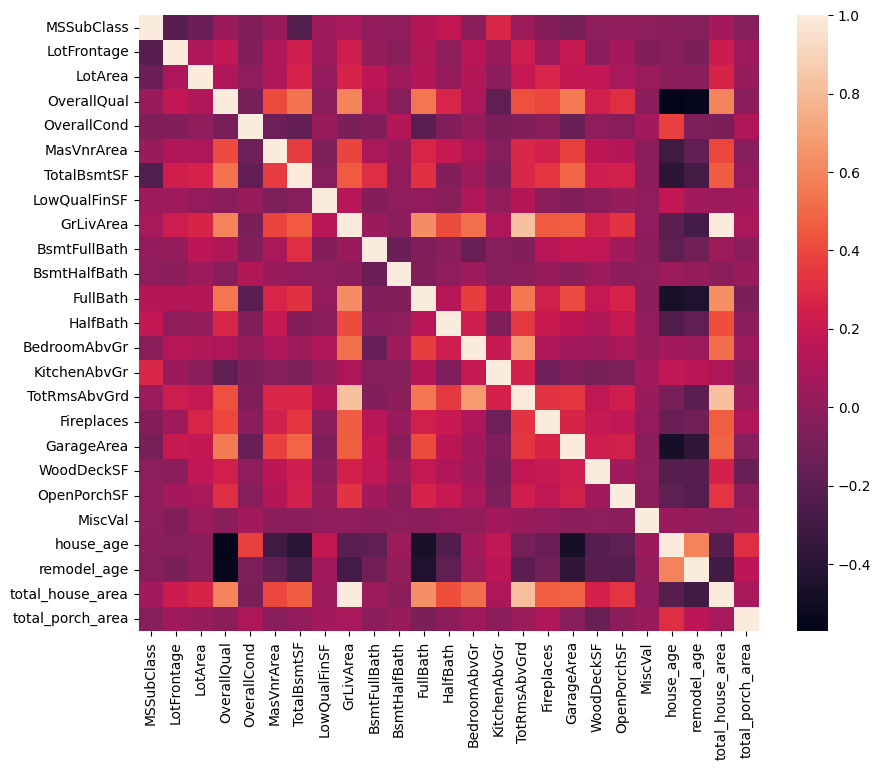

In [194]:
# Look at feature correlations

corr_matrix = df_dropped.select_dtypes(np.number).drop(columns = "SalePrice").corr()

plt.figure(figsize = (10,8))

sns.heatmap(corr_matrix)